In [1]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(tf.__version__)


2.21.0


In [2]:
data = pd.read_csv("../dataset/IMDB Dataset.csv")
print("Shape:", data.shape)

Shape: (50000, 2)


In [3]:
print(data.isnull().sum())
print(data.duplicated().sum())

review       0
sentiment    0
dtype: int64
418


In [5]:
data = data.drop_duplicates( subset=["review"]).reset_index(drop=True)
data.shape

(49582, 2)

In [7]:
print(data["sentiment"].value_counts())
print(data["sentiment"] .value_counts(normalize=True).mul(100).round(2))

sentiment
positive    24884
negative    24698
Name: count, dtype: int64
sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64


In [8]:
data["label"] = data["sentiment"].map({"negative": 0, "positive": 1})

In [10]:
data[["sentiment", "label"]].head(6)

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1
5,positive,1


In [11]:
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    
    # Keep only alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [13]:
sample_review = data["review"].iloc[0]

print("Orginal:")
print(sample_review[:1000])

print("Cleaned:")
print(clean_text(sample_review)[:1000])

Orginal:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due t

In [14]:
data["clean_review"] = data["review"].apply(clean_text)
print("completed.")

completed.


In [15]:
data[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive


In [16]:
empty_reviews = (
    data["clean_review"]
    .str.strip()
    .eq("")
    .sum()
)

print("Empty reviews after cleaning:", empty_reviews)

Empty reviews after cleaning: 0


In [17]:
X = data["clean_review"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.50,
    random_state=42,
    stratify=y_test
)

In [19]:
print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test))

Training samples  : 39665
Validation samples: 4958
Testing samples   : 4959


In [20]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
label
1    0.501878
0    0.498122
Name: proportion, dtype: float64

Validation distribution:
label
1    0.501815
0    0.498185
Name: proportion, dtype: float64

Test distribution:
label
1    0.501916
0    0.498084
Name: proportion, dtype: float64


In [21]:
MAX_VOCAB_SIZE = 30000

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Tokenizer fitted successfully.")
print("Vocabulary size:", len(tokenizer.word_index))

Tokenizer fitted successfully.
Vocabulary size: 90662


In [22]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [23]:
print("First training sequence:")
print(X_train_sequences[0][:30])

First training sequence:
[10, 236, 29, 5, 26421, 13, 4964, 3, 10, 83, 162, 9, 35, 26422, 453, 2759, 7896, 122, 2, 154, 10, 28, 107, 82, 697, 38, 1, 3797, 6, 536]


In [24]:
train_sequence_lengths = [
    len(sequence)
    for sequence in X_train_sequences
]

print("Minimum sequence length:",
      min(train_sequence_lengths))

print("Maximum sequence length:",
      max(train_sequence_lengths))

print("Mean sequence length:",
      round(np.mean(train_sequence_lengths), 2))

print("Median sequence length:",
      np.median(train_sequence_lengths))

Minimum sequence length: 6
Maximum sequence length: 2494
Mean sequence length: 234.54
Median sequence length: 176.0


In [25]:
percentiles = [50, 75, 80, 85, 90, 95, 97, 98, 99]

for p in percentiles:
    print(
        f"{p}th percentile:",
        int(np.percentile(train_sequence_lengths, p))
    )

50th percentile: 176
75th percentile: 285
80th percentile: 324
85th percentile: 377
90th percentile: 456
95th percentile: 597
97th percentile: 711
98th percentile: 791
99th percentile: 919


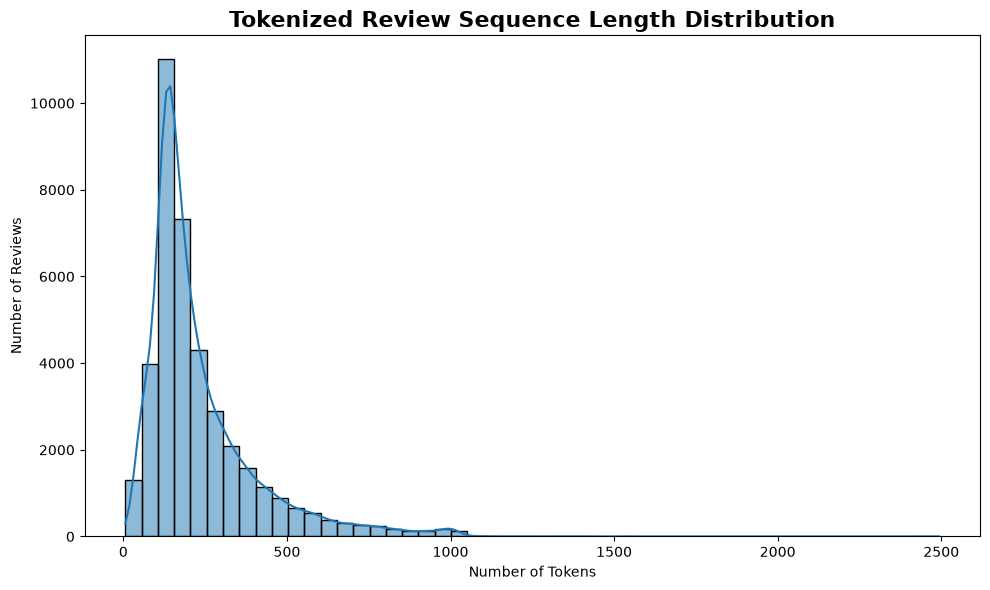

In [26]:
# sequence length distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    train_sequence_lengths,
    bins=50,
    kde=True
)

plt.title(
    "Tokenized Review Sequence Length Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Tokens")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.savefig(
    "../images/sequence_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
MAX_SEQUENCE_LENGTH = 500

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_padded = pad_sequences(
    X_val_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Padding completed successfully.")

Padding completed successfully.


In [28]:
print("X_train shape:", X_train_padded.shape)
print("X_val shape  :", X_val_padded.shape)
print("X_test shape :", X_test_padded.shape)

X_train shape: (39665, 500)
X_val shape  : (4958, 500)
X_test shape : (4959, 500)


In [29]:
print("First padded sequence:")
print(X_train_padded[0])

print("\nSequence length:")
print(len(X_train_padded[0]))

First padded sequence:
[   10   236    29     5 26421    13  4964     3    10    83   162     9
    35 26422   453  2759  7896   122     2   154    10    28   107    82
   697    38     1  3797     6   536     1    28  6507  1915 26423    23
   536  1407     1     3    28   107   440  4861   430   600  1741    38
     1  8572    34     1   536    10    28    83   545   440 26421    13
  4964   110   556    12    33    81   697    46    33  5831   536     3
   101   154     9     2  1831    10    28   113   163   107     8   569
  1207     2   885     7     8    65 14346     6  5831   536     1    41
     7     2  1920    32  1014     1    38     2   911    23    11  1749
     2  1749    17 26421    13  4964     7     4  1519    29    21   199
     1    38   536     7    24    35  5496  2559  1366    21    17    11
    16     3  3517   778    23     8     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0    

In [30]:
y_train = np.asarray(y_train)
y_val = np.asarray(y_val)
y_test = np.asarray(y_test)

In [31]:
print("X_train:", X_train_padded.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val_padded.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test_padded.shape)
print("y_test :", y_test.shape)

X_train: (39665, 500)
y_train: (39665,)
X_val  : (4958, 500)
y_val  : (4958,)
X_test : (4959, 500)
y_test : (4959,)


In [32]:
print("NaN values in training data:",
      np.isnan(X_train_padded).sum())

print("NaN values in validation data:",
      np.isnan(X_val_padded).sum())

print("NaN values in test data:",
      np.isnan(X_test_padded).sum())

NaN values in training data: 0
NaN values in validation data: 0
NaN values in test data: 0


In [33]:
print("Unique training labels:", np.unique(y_train))
print("Unique validation labels:", np.unique(y_val))
print("Unique test labels:", np.unique(y_test))

Unique training labels: [0 1]
Unique validation labels: [0 1]
Unique test labels: [0 1]


In [34]:
print(
    "Maximum token ID in training data:",
    X_train_padded.max()
)

print(
    "Maximum allowed vocabulary index:",
    MAX_VOCAB_SIZE - 1
)

Maximum token ID in training data: 29999
Maximum allowed vocabulary index: 29999


In [35]:
original_lengths = np.array(train_sequence_lengths)

num_truncated = np.sum(
    original_lengths > MAX_SEQUENCE_LENGTH
)

num_shorter = np.sum(
    original_lengths < MAX_SEQUENCE_LENGTH
)

print("Training reviews:", len(original_lengths))
print(
    "Reviews longer than 500 tokens:",
    num_truncated
)

print(
    "Percentage truncated:",
    round(
        num_truncated / len(original_lengths) * 100,
        2
    ),
    "%"
)

print(
    "Reviews shorter than 500 tokens:",
    num_shorter
)

print(
    "Percentage padded:",
    round(
        num_shorter / len(original_lengths) * 100,
        2
    ),
    "%"
)

Training reviews: 39665
Reviews longer than 500 tokens: 3166
Percentage truncated: 7.98 %
Reviews shorter than 500 tokens: 36476
Percentage padded: 91.96 %


In [36]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Model directory:", MODEL_DIR.resolve())

Model directory: C:\AximSoft_Weekly_Tasks\week_11\models


In [37]:
import pickle

TOKENIZER_PATH = MODEL_DIR / "tokenizer.pkl"

with open(TOKENIZER_PATH, "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully.")
print("Path:", TOKENIZER_PATH)

Tokenizer saved successfully.
Path: ..\models\tokenizer.pkl


In [38]:
preprocessing_config = {
    "max_vocab_size": MAX_VOCAB_SIZE,
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "padding": "post",
    "truncating": "post",
    "oov_token": "<OOV>"
}

with open(
    MODEL_DIR / "preprocessing_config.pkl",
    "wb"
) as file:
    pickle.dump(
        preprocessing_config,
        file
    )

print("Preprocessing configuration saved successfully.")

Preprocessing configuration saved successfully.


In [39]:
PROCESSED_DIR = Path("../processed_data")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_data_path = PROCESSED_DIR / "imdb_cleaned.csv"

data.to_csv(
    processed_data_path,
    index=False
)

print("Processed dataset saved successfully.")
print("Path:", processed_data_path.resolve())
print("Shape:", data.shape)

Processed dataset saved successfully.
Path: C:\AximSoft_Weekly_Tasks\week_11\processed_data\imdb_cleaned.csv
Shape: (49582, 4)
